Step-by-Step Simulation of Quantum Noise in Qiskit


Step 1: Import libraries


In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, errors
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


Step 2: Define a base quantum circuit

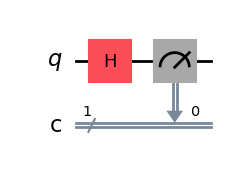

In [5]:
#Let’s create a simple Hadamard + measurement circuit:

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)
qc.draw('mpl')

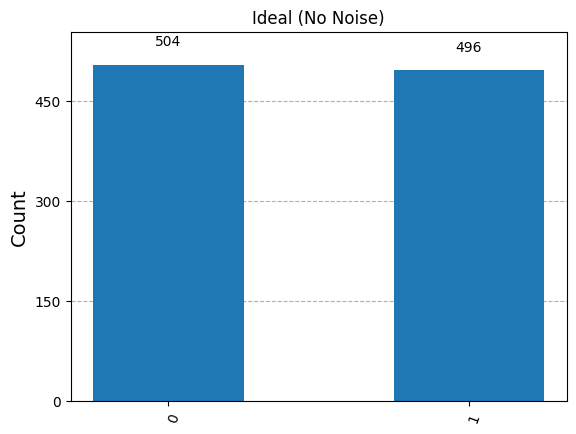

In [6]:
#Step 3: Create a simulator
ideal_sim = AerSimulator()
ideal_result = ideal_sim.run(transpile(qc, ideal_sim), shots=1000).result()
ideal_counts = ideal_result.get_counts()
plot_histogram(ideal_counts, title="Ideal (No Noise)")
#plt.show()

Step 4: Add different types of noise

Below are examples of how to create and apply each noise model

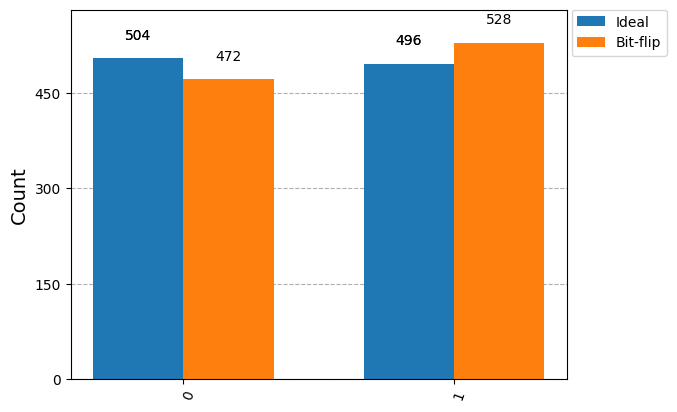

In [8]:
#Bit-flip noise
bitflip_error = errors.pauli_error([('X', 0.1), ('I', 0.9)]) # noise added
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(bitflip_error, ['measure'])

sim_bitflip = AerSimulator(noise_model=noise_model)
result_bitflip = sim_bitflip.run(transpile(qc, sim_bitflip), shots=1000).result()
counts_bitflip = result_bitflip.get_counts()
plot_histogram([ideal_counts, counts_bitflip], legend=['Ideal', 'Bit-flip'])
#plt.show()

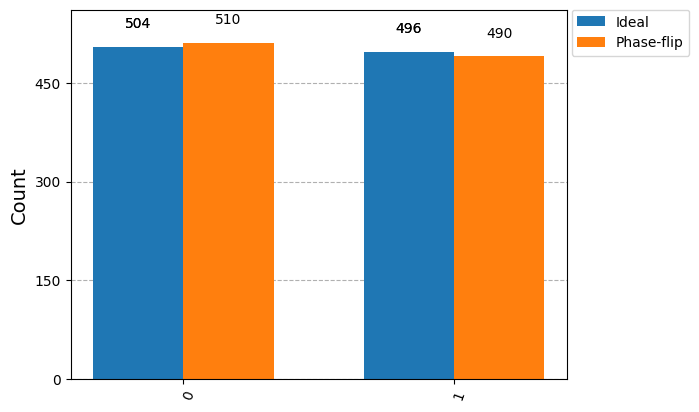

In [9]:
#Phase-flip noise
phaseflip_error = errors.pauli_error([('Z', 0.1), ('I', 0.9)])  # noise added
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(phaseflip_error, ['h'])  # apply to H gate

sim_phaseflip = AerSimulator(noise_model=noise_model)
result_phaseflip = sim_phaseflip.run(transpile(qc, sim_phaseflip), shots=1000).result()
counts_phaseflip = result_phaseflip.get_counts()
plot_histogram([ideal_counts, counts_phaseflip], legend=['Ideal', 'Phase-flip'])
#plt.show()

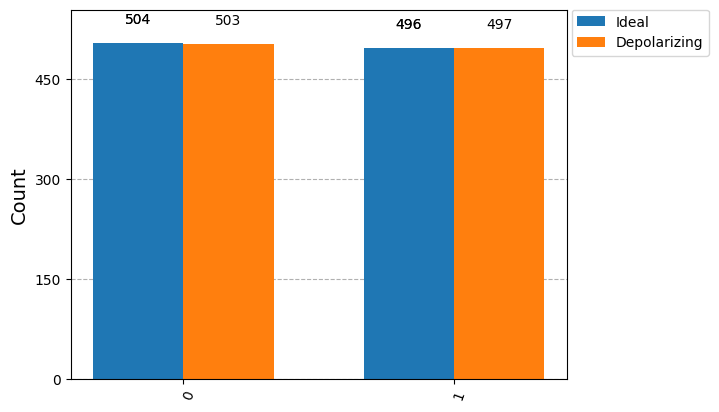

In [10]:
#Depolarizing noise
depolarizing_error = errors.depolarizing_error(0.05, 1)  # noise added
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error, ['h'])

sim_depolarizing = AerSimulator(noise_model=noise_model)
result_depolarizing = sim_depolarizing.run(transpile(qc, sim_depolarizing), shots=1000).result()
counts_depolarizing = result_depolarizing.get_counts()
plot_histogram([ideal_counts, counts_depolarizing], legend=['Ideal', 'Depolarizing'])
#plt.show()

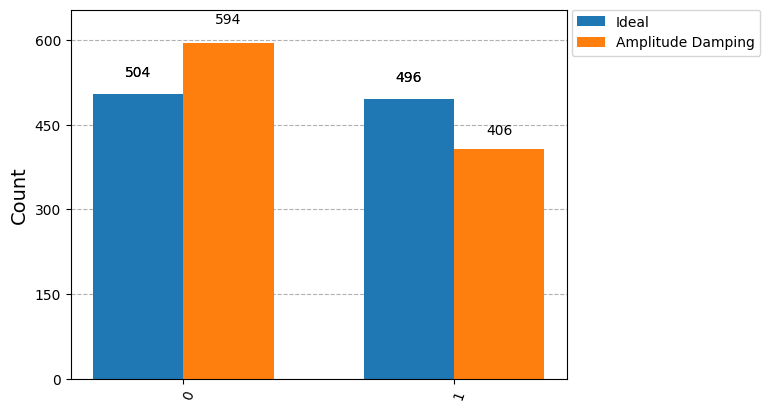

In [11]:
#Amplitude damping noise
amplitude_error = errors.amplitude_damping_error(0.2)   # noise added
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(amplitude_error, ['h'])

sim_amplitude = AerSimulator(noise_model=noise_model)
result_amplitude = sim_amplitude.run(transpile(qc, sim_amplitude), shots=1000).result()
counts_amplitude = result_amplitude.get_counts()
plot_histogram([ideal_counts, counts_amplitude], legend=['Ideal', 'Amplitude Damping'])
#plt.show()

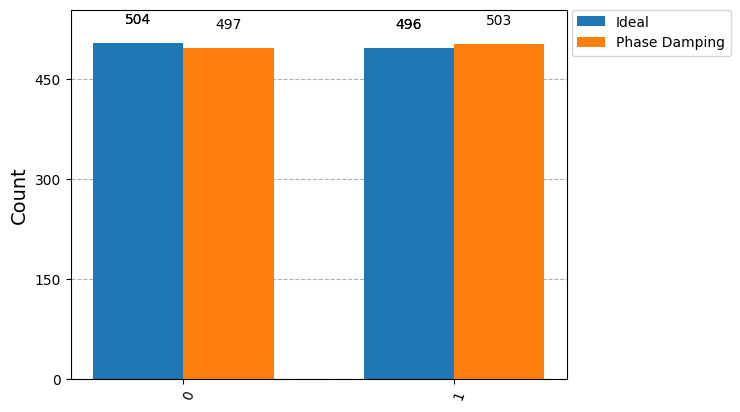

In [12]:
#Phase damping (dephasing) noise
phase_error = errors.phase_damping_error(0.2)   # noise added
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(phase_error, ['h'])

sim_phase = AerSimulator(noise_model=noise_model)
result_phase = sim_phase.run(transpile(qc, sim_phase), shots=1000).result()
counts_phase = result_phase.get_counts()
plot_histogram([ideal_counts, counts_phase], legend=['Ideal', 'Phase Damping'])
#plt.show()

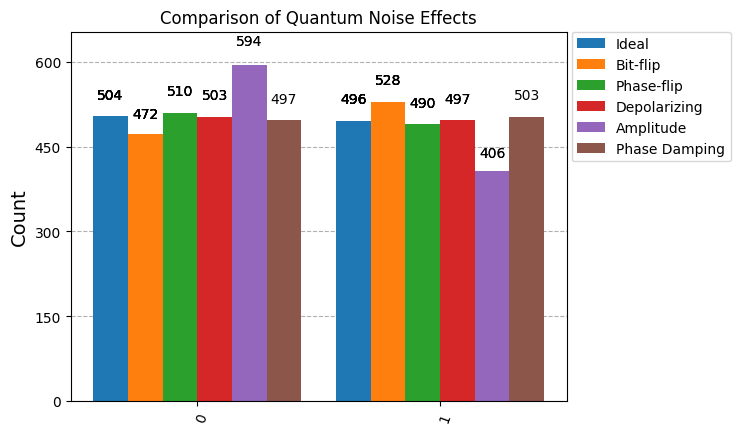

In [13]:
#Step 5: Compare all results

#You can combine all histograms to visually compare:

plot_histogram(
    [ideal_counts, counts_bitflip, counts_phaseflip, counts_depolarizing, counts_amplitude, counts_phase],
    legend=['Ideal', 'Bit-flip', 'Phase-flip', 'Depolarizing', 'Amplitude', 'Phase Damping'],
    title="Comparison of Quantum Noise Effects"
)
#plt.show()

Add and simulate bit flip, phase flip, amplitude damping noise in two-qubit Bell state. Perform simulation and compare results. (Select any one Bell state of your choice.)

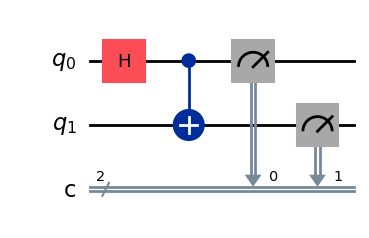

In [15]:
# Step 1: Create a 2-qubit Bell state circuit
# Using |Φ+> = (|00> + |11>)/√2
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

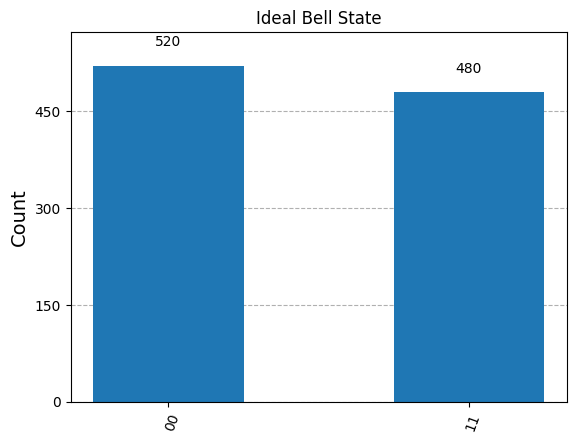

In [16]:
# Step 2: Ideal simulation
ideal_sim = AerSimulator()
ideal_result = ideal_sim.run(transpile(qc, ideal_sim), shots=1000).result()
ideal_counts = ideal_result.get_counts()
plot_histogram(ideal_counts, title="Ideal Bell State")
#plt.show()

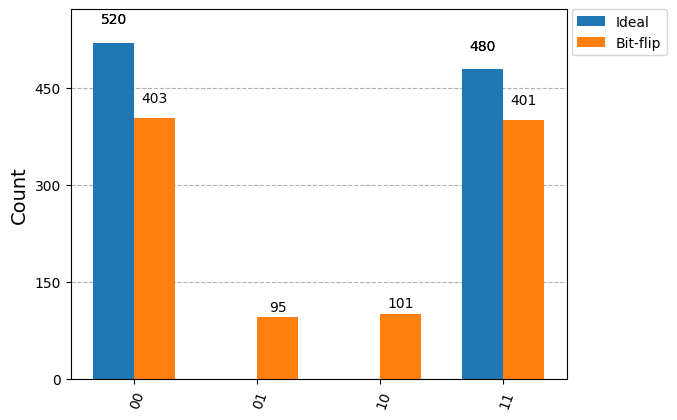

In [17]:
# Step 3: Bit-flip noise
bitflip_error = errors.pauli_error([('X', 0.1), ('I', 0.9)])
noise_bitflip = NoiseModel()
noise_bitflip.add_all_qubit_quantum_error(bitflip_error, ['h', 'measure'])

sim_bitflip = AerSimulator(noise_model=noise_bitflip)
result_bitflip = sim_bitflip.run(transpile(qc, sim_bitflip), shots=1000).result()
counts_bitflip = result_bitflip.get_counts()
plot_histogram([ideal_counts, counts_bitflip], legend=['Ideal', 'Bit-flip'])

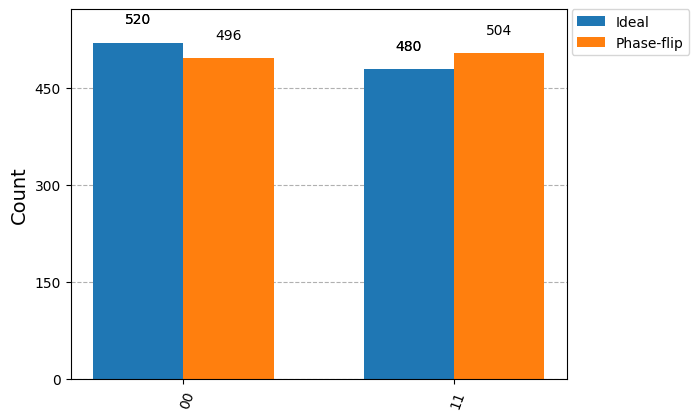

In [18]:
# Step 4: Phase-flip noise
phaseflip_error = errors.pauli_error([('Z', 0.1), ('I', 0.9)])
noise_phaseflip = NoiseModel()
noise_phaseflip.add_all_qubit_quantum_error(phaseflip_error, ['h', 'measure'])

sim_phaseflip = AerSimulator(noise_model=noise_phaseflip)
result_phaseflip = sim_phaseflip.run(transpile(qc, sim_phaseflip), shots=1000).result()
counts_phaseflip = result_phaseflip.get_counts()
plot_histogram([ideal_counts, counts_phaseflip], legend=['Ideal', 'Phase-flip'])

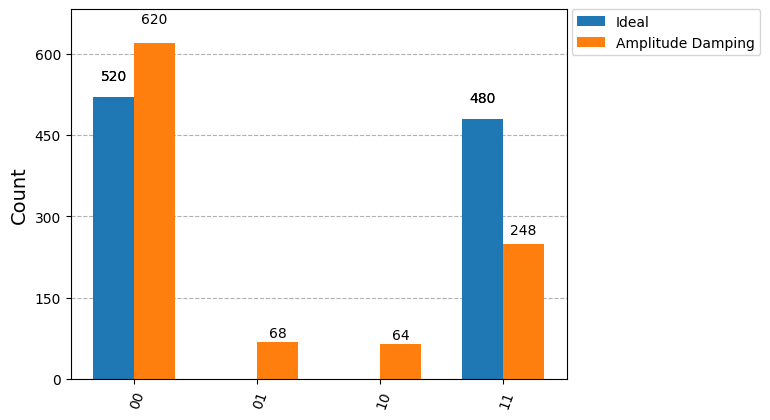

In [19]:
# Step 5: Amplitude damping noise
amplitude_error = errors.amplitude_damping_error(0.2)
noise_amplitude = NoiseModel()
noise_amplitude.add_all_qubit_quantum_error(amplitude_error, ['h', 'measure'])

sim_amplitude = AerSimulator(noise_model=noise_amplitude)
result_amplitude = sim_amplitude.run(transpile(qc, sim_amplitude), shots=1000).result()
counts_amplitude = result_amplitude.get_counts()
plot_histogram([ideal_counts, counts_amplitude], legend=['Ideal', 'Amplitude Damping'])

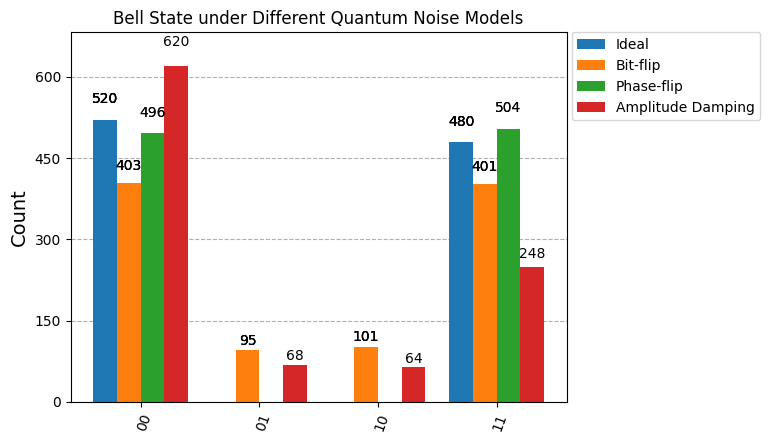

In [20]:
    # Step 6: Compare results
    plot_histogram(
        [ideal_counts, counts_bitflip, counts_phaseflip, counts_amplitude],
        legend=['Ideal', 'Bit-flip', 'Phase-flip', 'Amplitude Damping'],
        title="Bell State under Different Quantum Noise Models"
    )